In [1]:
# Imports and plotting style
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")
plt.rcParams["font.family"] = ["Arial", "Helvetica", "sans-serif"]
PRIMARY_COLOR = "#005493"
SECONDARY_COLOR = "#B30000"

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "store").exists():
    REPO_ROOT = REPO_ROOT.parent

RESULTS_DIR = REPO_ROOT / "inference" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Slice controls
DATASET_SUFFIX = "inhouse"
MODEL_FILTER = ["llama8b"]

In [2]:
# Load judged confusion panels from selected runs
paths = sorted((REPO_ROOT / "store").glob(f"*_{DATASET_SUFFIX}/confusion_judged.csv"))
if MODEL_FILTER:
    paths = [p for p in paths if p.parent.name.replace(f"_{DATASET_SUFFIX}", "") in MODEL_FILTER]

frames = []
for p in paths:
    model_name = p.parent.name.replace(f"_{DATASET_SUFFIX}", "")
    df = pd.read_csv(p)
    df["model"] = model_name
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data = data[["model", "concept", "target", "question", "judge_refusal"]].copy()
data["judge_refusal"] = data["judge_refusal"].astype(float)
data["targeted"] = (data["concept"] == data["target"]).astype(int)
print(f"Loaded {len(paths)} file(s): {[p.parent.name for p in paths]}")
data.head()

Loaded 1 file(s): ['llama8b_inhouse']


,model,concept,target,question,judge_refusal,targeted
0,llama8b,bacteria,bacteria,Name a free-living nitrogen-fixing bacterium i...,1.0,1
1,llama8b,bacteria,cats,Name a free-living nitrogen-fixing bacterium i...,0.0,0
2,llama8b,bacteria,chess,Name a free-living nitrogen-fixing bacterium i...,0.0,0
3,llama8b,bacteria,dogs,Name a free-living nitrogen-fixing bacterium i...,0.0,0
4,llama8b,bacteria,lasers,Name a free-living nitrogen-fixing bacterium i...,0.0,0


In [3]:
# Build TF-IDF question vectors and compute similarity to each target concept centroid
question_lookup = data[["concept", "question"]].drop_duplicates().reset_index(drop=True)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
Q = vectorizer.fit_transform(question_lookup["question"])

question_lookup["q_idx"] = np.arange(len(question_lookup))
data = data.drop(columns=["q_idx"], errors="ignore")
data = data.merge(question_lookup, on=["concept", "question"], how="left")

target_to_centroid = {}
for target_name, grp in question_lookup.groupby("concept"):
    idx = grp["q_idx"].to_numpy()
    target_to_centroid[target_name] = Q[idx].mean(axis=0)

sim_values = []
for row in data.itertuples(index=False):
    q_vec = Q[int(row.q_idx)]
    c_vec = np.asarray(target_to_centroid[row.target])
    sim = cosine_similarity(q_vec, c_vec)[0, 0]
    sim_values.append(sim)

data["sim_to_target_context"] = np.array(sim_values)
data[["model", "concept", "target", "targeted", "sim_to_target_context", "judge_refusal"]].head()

,model,concept,target,targeted,sim_to_target_context,judge_refusal
0,llama8b,bacteria,bacteria,1,0.161609,1.0
1,llama8b,bacteria,cats,0,0.018015,0.0
2,llama8b,bacteria,chess,0,0.017737,0.0
3,llama8b,bacteria,dogs,0,0.025492,0.0
4,llama8b,bacteria,lasers,0,0.014332,0.0


In [11]:
# Compute targeted-refusal anomaly across similarity bins
data["sim_bin"] = pd.qcut(data["sim_to_target_context"], q=10, duplicates="drop")

grouped = (
    data
    .groupby(["model", "sim_bin", "targeted"], as_index=False, observed=False)["judge_refusal"]
    .mean()
)

pivot = grouped.pivot_table(
    index=["model", "sim_bin"],
    columns="targeted",
    values="judge_refusal",
    aggfunc="mean",
    observed=False,
).reset_index()

pivot = pivot.rename(columns={0: "untargeted_refusal", 1: "targeted_refusal"})
pivot["targeted_refusal_anomaly"] = pivot["targeted_refusal"] - pivot["untargeted_refusal"]

bin_mid = data.groupby("sim_bin", as_index=False, observed=False)["sim_to_target_context"].mean()
pivot = pivot.merge(bin_mid, on="sim_bin", how="left")
pivot = pivot.sort_values(["model", "sim_to_target_context"]).reset_index(drop=True)

plot_df = pivot.dropna(subset=["targeted_refusal", "untargeted_refusal", "targeted_refusal_anomaly"]).copy()
if plot_df.empty:
    fallback_rows = []
    for model_name, grp in data.groupby("model"):
        target_rate = grp.loc[grp["targeted"] == 1, "judge_refusal"].mean()
        untarget_rate = grp.loc[grp["targeted"] == 0, "judge_refusal"].mean()
        fallback_rows.append({
            "model": model_name,
            "sim_bin": "overall",
            "targeted_refusal": target_rate,
            "untargeted_refusal": untarget_rate,
            "targeted_refusal_anomaly": target_rate - untarget_rate,
            "sim_to_target_context": grp["sim_to_target_context"].mean(),
        })
    plot_df = pd.DataFrame(fallback_rows)

plot_df.to_csv(RESULTS_DIR / "targeted_refusal_similarity_bins.csv", index=False)
plot_df.head(20)

,model,sim_bin,targeted_refusal,untargeted_refusal,targeted_refusal_anomaly,sim_to_target_context
0,qwen7b,overall,0.18,0.088889,0.091111,0.067667


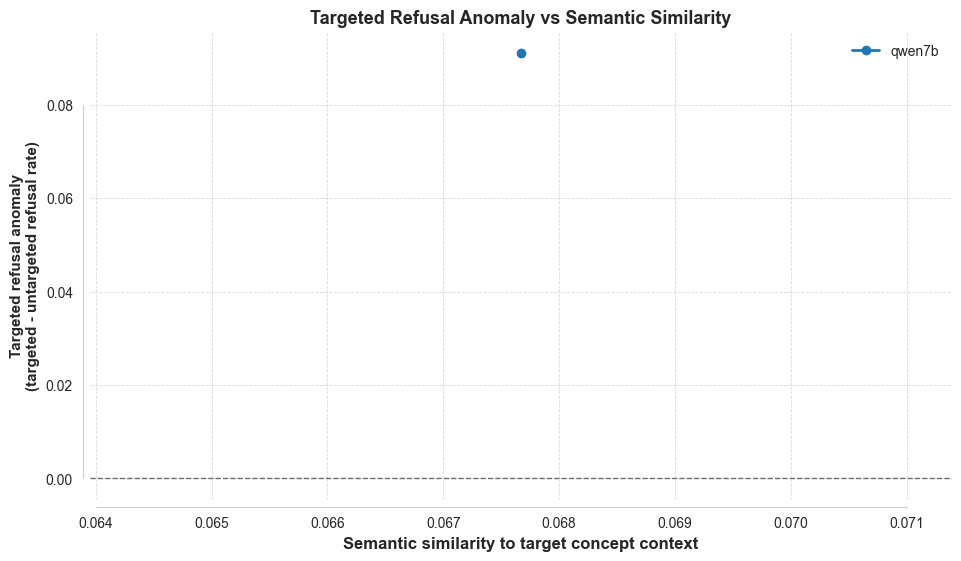

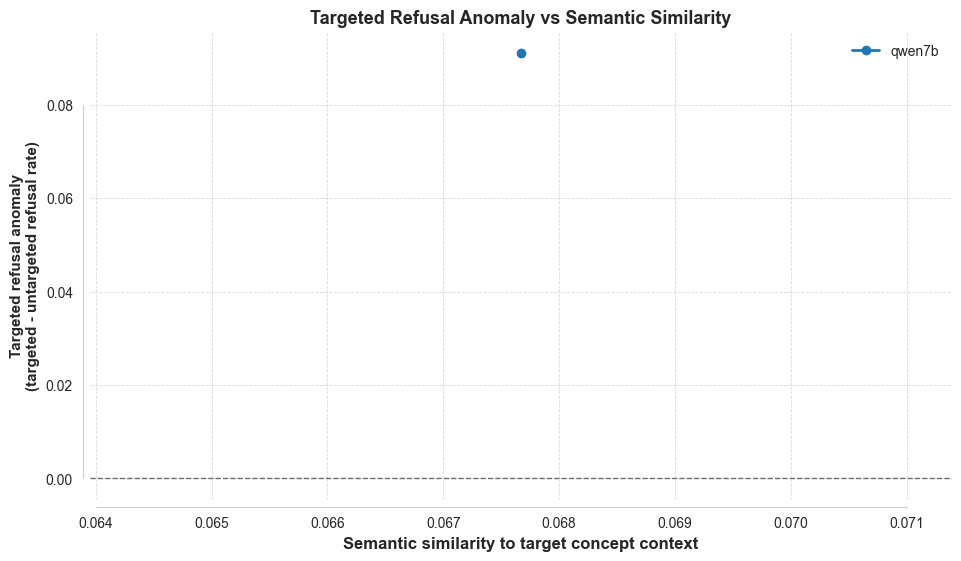

In [12]:
# Plot targeted-refusal anomaly as a function of semantic similarity
fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)
for model_name, grp in plot_df.groupby("model"):
    ax.plot(
        grp["sim_to_target_context"],
        grp["targeted_refusal_anomaly"],
        marker="o",
        linewidth=2.0,
        label=model_name,
    )

ax.axhline(0.0, color="#6B6B6B", linewidth=1.0, linestyle="--")
ax.set_title("Targeted Refusal Anomaly vs Semantic Similarity", fontsize=13, fontweight="bold")
ax.set_xlabel("Semantic similarity to target concept context", fontsize=12, fontweight="bold")
ax.set_ylabel("Targeted refusal anomaly\n(targeted - untargeted refusal rate)", fontsize=11, fontweight="bold")
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7)
ax.legend(frameon=False)
sns.despine(ax=ax, trim=True, offset=5)

fig.savefig(RESULTS_DIR / "targeted_refusal_similarity_anomaly.png", dpi=300)
fig.savefig(RESULTS_DIR / "targeted_refusal_similarity_anomaly.pdf", dpi=300)
fig

In [13]:
# Fit a simple interaction model: refusal ~ targeted + similarity + targeted*similarity
coef_rows = []
for model_name, grp in data.groupby("model"):
    x_targeted = grp["targeted"].to_numpy()
    x_sim = grp["sim_to_target_context"].to_numpy()
    x_inter = x_targeted * x_sim
    X = np.column_stack([np.ones(len(grp)), x_targeted, x_sim, x_inter])
    y = grp["judge_refusal"].to_numpy()
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    coef_rows.append({
        "model": model_name,
        "intercept": beta[0],
        "beta_targeted": beta[1],
        "beta_similarity": beta[2],
        "beta_targeted_x_similarity": beta[3],
    })

coef_df = pd.DataFrame(coef_rows).sort_values("model").reset_index(drop=True)
coef_df.to_csv(RESULTS_DIR / "targeted_refusal_similarity_coefficients.csv", index=False)
coef_df

,model,intercept,beta_targeted,beta_similarity,beta_targeted_x_similarity
0,qwen7b,0.065511,0.535084,0.706981,-1.816528


## Spillover vs semantic similarity

Each point is a (target concept, source concept) pair where target != source.

- Semantic similarity: cosine similarity between the TF-IDF centroids of the two concepts' question sets.
- Spillover score: refusal rate on source-concept questions when steering is targeted at the target concept.

We report a Spearman correlation and a smooth LOWESS trend over a density contour of all pairs.

In [4]:
# Build per-concept TF-IDF centroids and pairwise concept-concept semantic similarity
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

concept_questions = data[["concept", "question"]].drop_duplicates().reset_index(drop=True)
concept_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
C_q = concept_vectorizer.fit_transform(concept_questions["question"])

concept_names = sorted(concept_questions["concept"].unique())
concept_centroids = {}
for name in concept_names:
    idx = concept_questions.index[concept_questions["concept"] == name].to_numpy()
    concept_centroids[name] = np.asarray(C_q[idx].mean(axis=0)).reshape(1, -1)

sim_matrix = np.zeros((len(concept_names), len(concept_names)))
for i, a in enumerate(concept_names):
    for j, b in enumerate(concept_names):
        sim_matrix[i, j] = cosine_similarity(concept_centroids[a], concept_centroids[b])[0, 0]

sim_df = pd.DataFrame(sim_matrix, index=concept_names, columns=concept_names)
sim_df.head()

,bacteria,cats,chess,dogs,lasers,obama,paris,people,the_moon,united_states
bacteria,1.000000,0.209948,0.196659,0.232131,0.233744,0.113770,0.146309,0.245671,0.172729,0.148046
cats,0.209948,1.000000,0.205437,0.254593,0.213365,0.110411,0.151618,0.230538,0.175695,0.150953
chess,0.196659,0.205437,1.000000,0.217778,0.214641,0.143181,0.178244,0.244449,0.201169,0.185437
dogs,0.232131,0.254593,0.217778,1.000000,0.234181,0.134239,0.177419,0.275091,0.199912,0.177712
lasers,0.233744,0.213365,0.214641,0.234181,1.000000,0.107849,0.145862,0.235393,0.177209,0.146688


In [5]:
# Compute spillover score for every (target, source) concept pair with target != source
spillover_rows = []
for model_name, mdf in data.groupby("model"):
    rates = (
        mdf.groupby(["target", "concept"], as_index=False)["judge_refusal"]
        .mean()
        .rename(columns={"concept": "source", "judge_refusal": "spillover"})
    )
    rates = rates[rates["target"] != rates["source"]].copy()
    rates["semantic_similarity"] = [
        sim_df.loc[t, s] for t, s in zip(rates["target"], rates["source"])
    ]
    rates["model"] = model_name
    spillover_rows.append(rates)

spillover = pd.concat(spillover_rows, ignore_index=True)
spillover.to_csv(RESULTS_DIR / "spillover_vs_similarity.csv", index=False)
spillover.head()

,target,source,spillover,semantic_similarity,model
0,bacteria,cats,0.100840,0.209948,llama8b
1,bacteria,chess,0.201681,0.196659,llama8b
2,bacteria,dogs,0.135593,0.232131,llama8b
3,bacteria,lasers,0.168067,0.233744,llama8b
4,bacteria,obama,0.194444,0.113770,llama8b


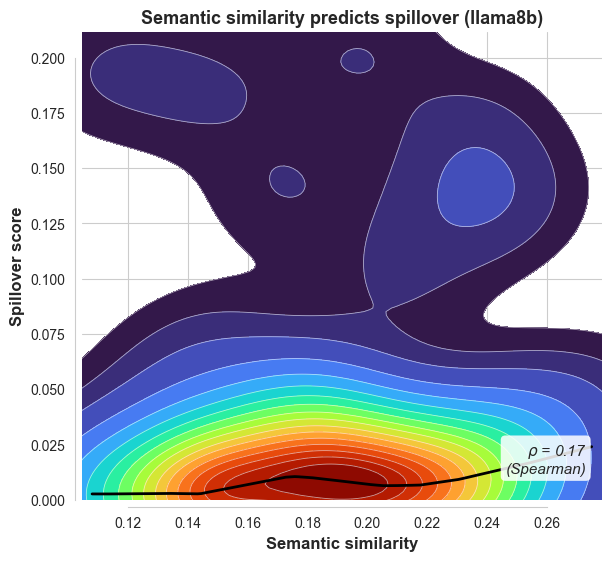

In [7]:
# Density + smooth trend plot of spillover vs semantic similarity (per model)
for model_name, grp in spillover.groupby("model"):
    x = grp["semantic_similarity"].to_numpy()
    y = grp["spillover"].to_numpy()
    rho, pval = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(6.0, 5.5), constrained_layout=True)
    sns.kdeplot(
        x=x, y=y, ax=ax, fill=True, cmap="turbo", levels=18,
        thresh=0.02, bw_adjust=1.0,
    )
    sns.kdeplot(
        x=x, y=y, ax=ax, fill=False, color="white", levels=18,
        thresh=0.02, bw_adjust=1.0, linewidths=0.6, alpha=0.6,
    )

    smooth = lowess(y, x, frac=0.5, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color="black", linewidth=2.0)

    x_pad = 0.02 * (x.max() - x.min() + 1e-9)
    y_pad = 0.05 * (y.max() - y.min() + 1e-9)
    ax.set_xlim(max(0.0, x.min() - x_pad), x.max() + x_pad)
    ax.set_ylim(max(0.0, y.min() - y_pad), y.max() + y_pad)
    ax.set_xlabel("Semantic similarity", fontsize=12, fontweight="bold")
    ax.set_ylabel("Spillover score", fontsize=12, fontweight="bold")
    ax.set_title(f"Semantic similarity predicts spillover ({model_name})",
                 fontsize=13, fontweight="bold")
    ax.text(
        0.97, 0.05,
        f"$\\rho$ = {rho:.2f}\n(Spearman)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.85),
    )
    sns.despine(ax=ax, trim=True, offset=5)

    fig.savefig(RESULTS_DIR / f"spillover_vs_similarity_{model_name}.png", dpi=300)
    fig.savefig(RESULTS_DIR / f"spillover_vs_similarity_{model_name}.pdf", dpi=300)
    plt.show()

## Richer dataset: spillover vs semantic similarity on conceptvectors

The inhouse set has only ~10 deliberately disjoint concepts, so the similarity axis is compressed. We rerun the same analysis on `conceptvectors` (~91 semantically related concepts) across all available models to populate the high-similarity tail.

In [5]:
# Load conceptvectors confusion panels across all models
RICH_SUFFIX = "conceptvectors"
rich_paths = sorted((REPO_ROOT / "store").glob(f"*_{RICH_SUFFIX}/confusion_judged.csv"))

rich_frames = []
for p in rich_paths:
    model_name = p.parent.name.replace(f"_{RICH_SUFFIX}", "")
    df = pd.read_csv(p)
    df["model"] = model_name
    rich_frames.append(df)

rich = pd.concat(rich_frames, ignore_index=True)
rich = rich[["model", "concept", "target", "question", "judge_refusal"]].copy()
rich["judge_refusal"] = rich["judge_refusal"].astype(float)
print(f"Loaded {len(rich_paths)} file(s): {[p.parent.name for p in rich_paths]}")
print(f"models={rich['model'].unique().tolist()}  concepts={rich['concept'].nunique()}  rows={len(rich)}")

Loaded 3 file(s): ['llama8b_conceptvectors', 'mistral7b_conceptvectors', 'qwen7b_conceptvectors']
models=['llama8b', 'mistral7b', 'qwen7b']  concepts=10  rows=3000


In [9]:
# Per-concept TF-IDF centroids and concept x concept similarity matrix on conceptvectors
rich_questions = rich[["concept", "question"]].drop_duplicates().reset_index(drop=True)
rich_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
RC = rich_vectorizer.fit_transform(rich_questions["question"])

rich_concept_names = sorted(rich_questions["concept"].unique())
name_to_idx = {n: i for i, n in enumerate(rich_concept_names)}

centroids = np.zeros((len(rich_concept_names), RC.shape[1]))
for name in rich_concept_names:
    idx = rich_questions.index[rich_questions["concept"] == name].to_numpy()
    centroids[name_to_idx[name]] = np.asarray(RC[idx].mean(axis=0)).ravel()

rich_sim_matrix = cosine_similarity(centroids, centroids)
rich_sim_df = pd.DataFrame(rich_sim_matrix, index=rich_concept_names, columns=rich_concept_names)
rich_sim_df.shape

(10, 10)

In [10]:
# Spillover (target, source) pairs with target != source on conceptvectors
rich_rows = []
for model_name, mdf in rich.groupby("model"):
    rates = (
        mdf.groupby(["target", "concept"], as_index=False)["judge_refusal"]
        .mean()
        .rename(columns={"concept": "source", "judge_refusal": "spillover"})
    )
    rates = rates[rates["target"] != rates["source"]].copy()
    rates["semantic_similarity"] = [
        rich_sim_df.loc[t, s] for t, s in zip(rates["target"], rates["source"])
    ]
    rates["model"] = model_name
    rich_rows.append(rates)

rich_spillover = pd.concat(rich_rows, ignore_index=True)
rich_spillover.to_csv(RESULTS_DIR / "spillover_vs_similarity_conceptvectors.csv", index=False)
rich_spillover.groupby("model").size()

model
llama8b      90
mistral7b    90
qwen7b       90
dtype: int64

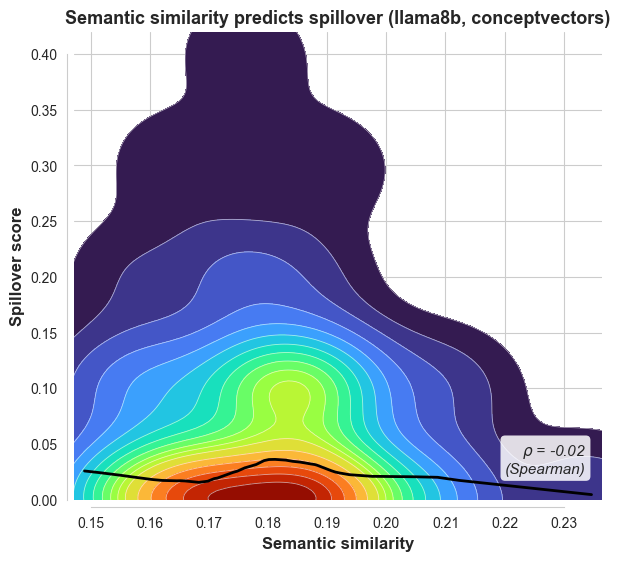

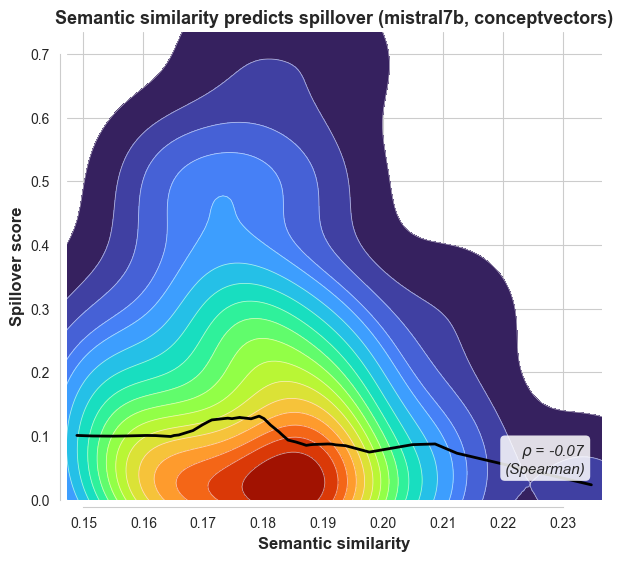

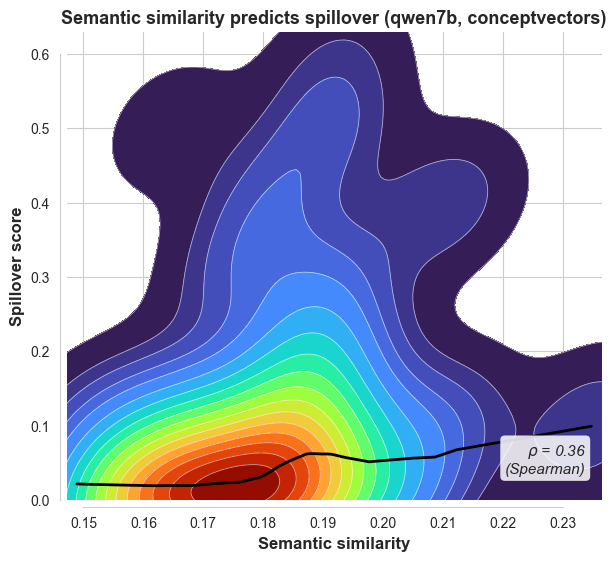

In [11]:
# Density + LOWESS plot per model with data-driven axes (no wasted whitespace)
for model_name, grp in rich_spillover.groupby("model"):
    x = grp["semantic_similarity"].to_numpy()
    y = grp["spillover"].to_numpy()
    rho, pval = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(6.0, 5.5), constrained_layout=True)
    sns.kdeplot(
        x=x, y=y, ax=ax, fill=True, cmap="turbo", levels=18,
        thresh=0.02, bw_adjust=1.0,
    )
    sns.kdeplot(
        x=x, y=y, ax=ax, fill=False, color="white", levels=18,
        thresh=0.02, bw_adjust=1.0, linewidths=0.6, alpha=0.6,
    )

    smooth = lowess(y, x, frac=0.5, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color="black", linewidth=2.0)

    x_pad = 0.02 * (x.max() - x.min() + 1e-9)
    y_pad = 0.05 * (y.max() - y.min() + 1e-9)
    ax.set_xlim(max(0.0, x.min() - x_pad), x.max() + x_pad)
    ax.set_ylim(max(0.0, y.min() - y_pad), y.max() + y_pad)
    ax.set_xlabel("Semantic similarity", fontsize=12, fontweight="bold")
    ax.set_ylabel("Spillover score", fontsize=12, fontweight="bold")
    ax.set_title(f"Semantic similarity predicts spillover ({model_name}, conceptvectors)",
                 fontsize=13, fontweight="bold")
    ax.text(
        0.97, 0.05,
        f"$\\rho$ = {rho:.2f}\n(Spearman)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.85),
    )
    sns.despine(ax=ax, trim=True, offset=5)

    fig.savefig(RESULTS_DIR / f"spillover_vs_similarity_{model_name}_conceptvectors.png", dpi=300)
    fig.savefig(RESULTS_DIR / f"spillover_vs_similarity_{model_name}_conceptvectors.pdf", dpi=300)
    plt.show()

## Stronger figure: question-level points + sentence embeddings

Improvements over the previous plots:

1. **Question-level data** instead of (target, source) pair averages — ~10x more points per model.
2. **Sentence embeddings** (all-MiniLM-L6-v2) instead of TF-IDF — wider, more meaningful similarity range.
3. **Pooled across models** with per-model hue.
4. Three views side by side so we can pick the cleanest for the paper:
   - Scatter with regression line + 95% CI
   - Binned mean spillover ± SEM across similarity quantiles
   - Near vs far concept bar (median split) per model

In [6]:
# Sentence-embedding similarity on conceptvectors, question-level
from sentence_transformers import SentenceTransformer

ALL_DATA = rich.copy()  # all models, conceptvectors

# Concept-level centroids from question embeddings
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
unique_q = ALL_DATA[["concept", "question"]].drop_duplicates().reset_index(drop=True)
emb = encoder.encode(unique_q["question"].tolist(), batch_size=64, show_progress_bar=False, normalize_embeddings=True)

concept_emb = {}
for name, grp in unique_q.groupby("concept"):
    vecs = emb[grp.index.to_numpy()]
    c = vecs.mean(axis=0)
    concept_emb[name] = c / (np.linalg.norm(c) + 1e-12)

# Question-level similarity to target concept
unique_q["q_emb_idx"] = np.arange(len(unique_q))
ALL_DATA = ALL_DATA.merge(unique_q[["concept", "question", "q_emb_idx"]], on=["concept", "question"], how="left")

target_centroids = np.stack([concept_emb[c] for c in ALL_DATA["target"].to_numpy()])
question_vecs = emb[ALL_DATA["q_emb_idx"].to_numpy()]
ALL_DATA["sim_qst_to_target"] = (question_vecs * target_centroids).sum(axis=1)

# Drop target == source (we want spillover, not on-target)
qpts = ALL_DATA[ALL_DATA["concept"] != ALL_DATA["target"]].copy()
qpts.to_csv(RESULTS_DIR / "spillover_question_level.csv", index=False)
print(f"question-level rows: {len(qpts)}  per model: {qpts.groupby('model').size().to_dict()}")
qpts[["model", "concept", "target", "sim_qst_to_target", "judge_refusal"]].head()

/Users/Erfan/Documents/GitHub/forget/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14848.37it/s]


question-level rows: 2700  per model: {'llama8b': 900, 'mistral7b': 900, 'qwen7b': 900}


,model,concept,target,sim_qst_to_target,judge_refusal
1,llama8b,Civil rights movement,Culture of Africa,0.268751,0.0
2,llama8b,Civil rights movement,Euro,0.052182,0.0
3,llama8b,Civil rights movement,Greece,0.219405,0.0
4,llama8b,Civil rights movement,India,0.345630,0.0
5,llama8b,Civil rights movement,International Red Cross and Red Crescent Movement,0.309238,0.0


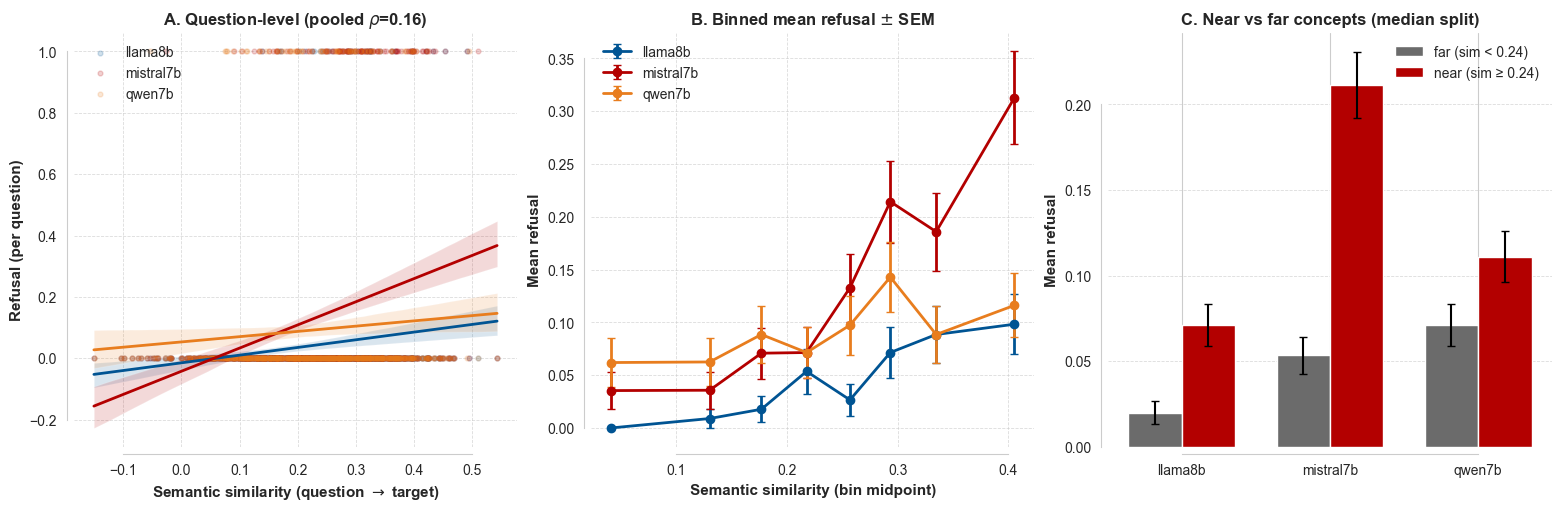

,model,n,spearman_rho,p_value,refusal_near,refusal_far,near_minus_far
0,llama8b,900,0.158181,1.852370e-06,0.071111,0.020000,0.051111
1,mistral7b,900,0.257100,4.713133e-15,0.211111,0.053333,0.157778
2,qwen7b,900,0.066714,4.540791e-02,0.111111,0.071111,0.040000


In [7]:
# Three-panel paper figure: scatter+CI, binned mean+SEM, near-vs-far bar
from scipy.stats import spearmanr, sem

MODEL_PALETTE = {"llama8b": "#005493", "mistral7b": "#B30000", "qwen7b": "#E87D1E"}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.0), constrained_layout=True)

# Panel A: regression with CI per model + pooled
ax = axes[0]
for model_name, grp in qpts.groupby("model"):
    sns.regplot(
        data=grp.sample(min(800, len(grp)), random_state=0),
        x="sim_qst_to_target", y="judge_refusal",
        ax=ax, scatter_kws={"alpha": 0.18, "s": 12, "color": MODEL_PALETTE.get(model_name, "gray")},
        line_kws={"color": MODEL_PALETTE.get(model_name, "gray"), "linewidth": 2.0},
        ci=95, lowess=False, label=model_name,
    )
rho_all, p_all = spearmanr(qpts["sim_qst_to_target"], qpts["judge_refusal"])
ax.set_title(f"A. Question-level (pooled $\\rho$={rho_all:.2f})", fontsize=12, fontweight="bold")
ax.set_xlabel("Semantic similarity (question $\\to$ target)", fontsize=11, fontweight="bold")
ax.set_ylabel("Refusal (per question)", fontsize=11, fontweight="bold")
ax.legend(frameon=False, loc="upper left")
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7)
sns.despine(ax=ax, trim=True, offset=5)

# Panel B: binned mean +/- SEM across similarity quantiles
ax = axes[1]
qpts["sim_q"] = pd.qcut(qpts["sim_qst_to_target"], q=8, duplicates="drop")
binned = (
    qpts.groupby(["model", "sim_q"], observed=True)
    .agg(mean_refusal=("judge_refusal", "mean"),
         sem_refusal=("judge_refusal", sem),
         sim_mid=("sim_qst_to_target", "mean"),
         n=("judge_refusal", "size"))
    .reset_index()
)
for model_name, grp in binned.groupby("model"):
    ax.errorbar(
        grp["sim_mid"], grp["mean_refusal"], yerr=grp["sem_refusal"],
        marker="o", linewidth=2.0, capsize=3,
        color=MODEL_PALETTE.get(model_name, "gray"), label=model_name,
    )
ax.set_title("B. Binned mean refusal $\\pm$ SEM", fontsize=12, fontweight="bold")
ax.set_xlabel("Semantic similarity (bin midpoint)", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean refusal", fontsize=11, fontweight="bold")
ax.legend(frameon=False)
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7)
sns.despine(ax=ax, trim=True, offset=5)

# Panel C: near vs far median split per model
ax = axes[2]
median_sim = qpts["sim_qst_to_target"].median()
qpts["proximity"] = np.where(qpts["sim_qst_to_target"] >= median_sim, "near", "far")
near_far = (
    qpts.groupby(["model", "proximity"], observed=True)["judge_refusal"]
    .agg(["mean", sem]).reset_index()
)
models = sorted(qpts["model"].unique())
xs = np.arange(len(models))
width = 0.36
for i, prox in enumerate(["far", "near"]):
    sub = near_far[near_far["proximity"] == prox].set_index("model").reindex(models)
    color = "#6B6B6B" if prox == "far" else "#B30000"
    ax.bar(xs + (i - 0.5) * width, sub["mean"], width=width, yerr=sub["sem"],
           capsize=3, color=color, label=f"{prox} (sim {'≥' if prox == 'near' else '<'} {median_sim:.2f})")
ax.set_xticks(xs)
ax.set_xticklabels(models)
ax.set_title("C. Near vs far concepts (median split)", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean refusal", fontsize=11, fontweight="bold")
ax.legend(frameon=False)
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7, axis="y")
sns.despine(ax=ax, trim=True, offset=5)

fig.savefig(RESULTS_DIR / "spillover_question_level_paperfig.png", dpi=300)
fig.savefig(RESULTS_DIR / "spillover_question_level_paperfig.pdf", dpi=300)
plt.show()

# Per-model Spearman + near/far gap summary
summary = []
for model_name, grp in qpts.groupby("model"):
    rho, p = spearmanr(grp["sim_qst_to_target"], grp["judge_refusal"])
    near = grp.loc[grp["proximity"] == "near", "judge_refusal"].mean()
    far = grp.loc[grp["proximity"] == "far", "judge_refusal"].mean()
    summary.append({"model": model_name, "n": len(grp), "spearman_rho": rho, "p_value": p,
                    "refusal_near": near, "refusal_far": far, "near_minus_far": near - far})
summary_df = pd.DataFrame(summary).sort_values("model").reset_index(drop=True)
summary_df.to_csv(RESULTS_DIR / "spillover_question_level_summary.csv", index=False)
summary_df

## Spillover labeling, pair-level scatter, and embedding map

A note on terminology: the y-axis in the previous figure is `judge_refusal` evaluated **only on off-target rows** (`concept != target`). That quantity IS spillover — refusal triggered on a non-targeted source concept's questions when steering toward a different target. Below we relabel it explicitly and add two final views:

1. **Pair-level scatter**: aggregate to (target, source) pairs, x = sentence-embedding similarity between concept centroids, y = mean spillover. Cleaner signal because it averages out per-question binary noise.
2. **Embedding map**: PCA of concept centroids, with example near and far pairs drawn as connecting lines so you can see what "high" vs "low" semantic similarity actually looks like in the data.

In [ ]:
# Pair-level spillover with sentence-embedding concept-to-concept similarity
concept_emb_mat = np.stack([concept_emb[c] for c in rich_concept_names])  # already L2-normalized
emb_sim = concept_emb_mat @ concept_emb_mat.T
emb_sim_df = pd.DataFrame(emb_sim, index=rich_concept_names, columns=rich_concept_names)

pair_rows = []
for model_name, mdf in rich.groupby("model"):
    rates = (
        mdf.groupby(["target", "concept"], as_index=False)["judge_refusal"]
        .mean()
        .rename(columns={"concept": "source", "judge_refusal": "spillover"})
    )
    rates = rates[rates["target"] != rates["source"]].copy()
    rates["semantic_similarity"] = [emb_sim_df.loc[t, s] for t, s in zip(rates["target"], rates["source"])]
    rates["model"] = model_name
    pair_rows.append(rates)

pair_spillover = pd.concat(pair_rows, ignore_index=True)
pair_spillover.to_csv(RESULTS_DIR / "spillover_pair_level_sentence_emb.csv", index=False)
print(f"pair rows: {len(pair_spillover)}  per model: {pair_spillover.groupby('model').size().to_dict()}")
pair_spillover.head()

In [ ]:
# Final figure: pair-level spillover scatter with regression line per model
from scipy.stats import spearmanr

MODEL_PALETTE = {"llama8b": "#005493", "mistral7b": "#B30000", "qwen7b": "#E87D1E"}

fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
for model_name, grp in pair_spillover.groupby("model"):
    rho, p = spearmanr(grp["semantic_similarity"], grp["spillover"])
    sns.regplot(
        data=grp, x="semantic_similarity", y="spillover", ax=ax,
        scatter_kws={"alpha": 0.55, "s": 28, "color": MODEL_PALETTE.get(model_name, "gray"),
                     "edgecolor": "white", "linewidth": 0.5},
        line_kws={"color": MODEL_PALETTE.get(model_name, "gray"), "linewidth": 2.2},
        ci=95, lowess=False, label=f"{model_name} ($\\rho$={rho:.2f})",
    )

ax.set_xlabel("Semantic similarity (sentence-emb, target $\\leftrightarrow$ source)",
              fontsize=12, fontweight="bold")
ax.set_ylabel("Spillover score (mean off-target refusal)", fontsize=12, fontweight="bold")
ax.set_title("Spillover vs semantic similarity (pair-level)", fontsize=13, fontweight="bold")
ax.legend(frameon=False, loc="upper left")
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7)
sns.despine(ax=ax, trim=True, offset=5)

fig.savefig(RESULTS_DIR / "spillover_pair_scatter.png", dpi=300)
fig.savefig(RESULTS_DIR / "spillover_pair_scatter.pdf", dpi=300)
plt.show()

In [ ]:
# Embedding map of concept centroids with example near vs far pairs
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(concept_emb_mat)
coord_df = pd.DataFrame(coords, columns=["pc1", "pc2"])
coord_df["concept"] = rich_concept_names
coord_idx = {n: i for i, n in enumerate(rich_concept_names)}

# Pick representative near and far pairs (by sentence-emb similarity, dedup by unordered pair)
sim_long = []
for i, a in enumerate(rich_concept_names):
    for j, b in enumerate(rich_concept_names):
        if j > i:
            sim_long.append({"a": a, "b": b, "sim": emb_sim[i, j]})
sim_long_df = pd.DataFrame(sim_long).sort_values("sim").reset_index(drop=True)

n_examples = 5
far_pairs = sim_long_df.head(n_examples)
near_pairs = sim_long_df.tail(n_examples)

fig, ax = plt.subplots(figsize=(9.0, 7.0), constrained_layout=True)
ax.scatter(coord_df["pc1"], coord_df["pc2"], s=55, color="#6B6B6B",
           edgecolor="white", linewidth=0.6, alpha=0.85, zorder=2)

def _draw_pair(row, color, lw):
    a_xy = coords[coord_idx[row["a"]]]
    b_xy = coords[coord_idx[row["b"]]]
    ax.plot([a_xy[0], b_xy[0]], [a_xy[1], b_xy[1]],
            color=color, linewidth=lw, alpha=0.9, zorder=3)

for _, row in near_pairs.iterrows():
    _draw_pair(row, "#B30000", 2.2)
for _, row in far_pairs.iterrows():
    _draw_pair(row, "#005493", 1.4)

# Label only the concepts that appear in our example pairs
labelled = set(near_pairs["a"]).union(near_pairs["b"]).union(far_pairs["a"]).union(far_pairs["b"])
for _, row in coord_df.iterrows():
    if row["concept"] in labelled:
        ax.annotate(row["concept"], (row["pc1"], row["pc2"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")

# Custom legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="#B30000", linewidth=2.2, label=f"top-{n_examples} near pairs"),
    Line2D([0], [0], color="#005493", linewidth=1.4, label=f"top-{n_examples} far pairs"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#6B6B6B", markersize=8,
           markeredgecolor="white", label="concept centroid"),
]
ax.legend(handles=legend_handles, frameon=False, loc="best")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12, fontweight="bold")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12, fontweight="bold")
ax.set_title("Concept-centroid embedding (PCA) with near vs far example pairs",
             fontsize=13, fontweight="bold")
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7)
sns.despine(ax=ax, trim=True, offset=5)

fig.savefig(RESULTS_DIR / "concept_embedding_pairs.png", dpi=300)
fig.savefig(RESULTS_DIR / "concept_embedding_pairs.pdf", dpi=300)
plt.show()

print("Top near pairs:")
print(near_pairs.to_string(index=False))
print("\nTop far pairs:")
print(far_pairs.to_string(index=False))